In [ ]:
"""
APM_52065_EP — Crypto Flash Crash October 2025
SECTION 3: Linear Time Series Analysis
  
Dependencies:
    pip install yfinance statsmodels scipy matplotlib numpy
 
Output: all figures saved as PDF in ./figures/
        all tables printed to console 
"""

'\nAPM_52065_EP — Crypto Flash Crash October 2025\nSECTION 3: Linear Time Series Analysis\n\nRun after data_download.py\n\nDependencies:\n    pip install yfinance statsmodels scipy matplotlib numpy\n    (no external fracdiff package needed — implemented from scratch below)\n\nOutput: all figures saved as PDF in ./figures/\n        all tables printed to console (copy into LaTeX)\n'

In [6]:
# ============================================================
# 0. IMPORTS
# ============================================================
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import signal
from scipy.stats import kurtosis, skew
 
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
 
# fracdiff is NOT required — fractional differencing is implemented
# from scratch below using numpy (works on any Python version).
 
warnings.filterwarnings("ignore")
os.makedirs("figures", exist_ok=True)
 
# ── Matplotlib global style ───────────────────────────────────
plt.rcParams.update({
    "figure.dpi":        150,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.alpha":        0.3,
    "font.size":         11,
})
COLORS = {"BTC": "#1f77b4", "ETH": "#ff7f0e"}

In [7]:
# ============================================================
# 1. DATA LOADING
# ============================================================
def load_data():
    """
    Load hourly BTC-USD and ETH-USD prices.
    Priority: local CSV -> yfinance -> synthetic fallback.
    """
    # 1) Local CSV (fastest — run data_download.py first)
    try:
        btc = pd.read_csv("data/BTC_USD_1h_2025.csv",
                          index_col=0, parse_dates=True).squeeze()
        eth = pd.read_csv("data/ETH_USD_1h_2025.csv",
                          index_col=0, parse_dates=True).squeeze()
        print(f"[DATA] Loaded from CSV  BTC={len(btc)} obs, ETH={len(eth)} obs")
        return btc, eth
    except FileNotFoundError:
        pass
 
    # 2) yfinance live download
    try:
        import yfinance as yf
        print("[DATA] Downloading from yfinance...")
        s1_b = yf.download("BTC-USD", start="2025-01-01", end="2025-07-01",
                            interval="1h", progress=False)["Close"]
        s2_b = yf.download("BTC-USD", start="2025-07-01", end="2026-01-01",
                            interval="1h", progress=False)["Close"]
        s1_e = yf.download("ETH-USD", start="2025-01-01", end="2025-07-01",
                            interval="1h", progress=False)["Close"]
        s2_e = yf.download("ETH-USD", start="2025-07-01", end="2026-01-01",
                            interval="1h", progress=False)["Close"]
        btc = pd.concat([s1_b, s2_b]).sort_index()
        eth = pd.concat([s1_e, s2_e]).sort_index()
        btc = btc[~btc.index.duplicated()]
        eth = eth[~eth.index.duplicated()]
        btc.name, eth.name = "BTC", "ETH"
        print(f"[DATA] Download OK  BTC={len(btc)} obs, ETH={len(eth)} obs")
        return btc, eth
    except Exception as e:
        print(f"[DATA] yfinance failed ({e}). Using synthetic data.")
        return _synthetic_data()
 
 
def _synthetic_data():
    """
    Synthetic data reproducing stylised facts of the Oct 10 Flash Crash.
    Used for offline testing only.
    """
    np.random.seed(42)
    n = 8760
    dates = pd.date_range("2025-01-01", periods=n, freq="h")
    crash_idx = 6816
 
    r_btc = np.random.normal(5e-5, 0.020, n)
    r_eth = np.random.normal(5e-5, 0.025, n)
 
    # Volatility clustering around the crash
    for i in range(crash_idx - 48, crash_idx + 120):
        factor = 1 + 4 * np.exp(-0.05 * abs(i - crash_idx))
        r_btc[i] *= factor
        r_eth[i] *= factor * 1.2
 
    r_btc[crash_idx]         = -0.0207   # BTC peak drop at 20:00 UTC
    r_eth[crash_idx - 5]     = -0.0423   # ETH peak drop at 15:00 UTC
 
    btc = pd.Series(97_000 * np.exp(np.cumsum(r_btc)), index=dates, name="BTC")
    eth = pd.Series(3_400  * np.exp(np.cumsum(r_eth)), index=dates, name="ETH")
    return btc, eth
 

In [8]:
# ============================================================
# 2. PRE-PROCESSING
# ============================================================
def log_returns(price: pd.Series) -> pd.Series:
    """Compute hourly log-returns: r_t = log(P_t / P_{t-1})."""
    return np.log(price / price.shift(1)).dropna()

In [9]:
# ============================================================
# 3.1 DESCRIPTIVE STATISTICS
# ============================================================
def descriptive_stats(returns: dict) -> pd.DataFrame:
    """
    Table 1 — Descriptive statistics of log-returns.
    Columns: n, mean, std, skewness, excess kurtosis, min, max.
    """
    rows = []
    for name, s in returns.items():
        rows.append({
            "Series":            name,
            "n":                 len(s),
            "Mean (×1e-4)":      round(s.mean() * 1e4, 4),
            "Std dev (%)":       round(s.std() * 100, 4),
            "Skewness":          round(skew(s), 4),
            "Excess kurtosis":   round(kurtosis(s), 4),
            "Min (%)":           round(s.min() * 100, 4),
            "Max (%)":           round(s.max() * 100, 4),
        })
    return pd.DataFrame(rows).set_index("Series")
 
 
def plot_overview(btc_price, eth_price, btc_ret, eth_ret,
                  crash_start="2025-10-10 15:00",
                  crash_end="2025-10-10 23:00"):
    """
    Figure 5 — Price levels and log-returns for October 2025.
    """
    oct = slice("2025-10-01", "2025-10-31")
    cs  = pd.Timestamp(crash_start)
    ce  = pd.Timestamp(crash_end)
 
    fig, axes = plt.subplots(2, 2, figsize=(14, 7))
    fig.suptitle("Overview — October 2025", fontsize=13, fontweight="bold")
 
    for ax, s, lbl, key in [
        (axes[0, 0], btc_price[oct], "BTC price (USD)", "BTC"),
        (axes[0, 1], eth_price[oct], "ETH price (USD)", "ETH"),
    ]:
        ax.plot(s, linewidth=0.9, color=COLORS[key])
        ax.axvspan(cs, ce, color="red", alpha=0.15, label="Flash Crash")
        ax.set_title(lbl)
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%d/%m"))
        ax.legend(fontsize=8)
        ax.set_xlabel("Date (Oct 2025)")
 
    for ax, s, lbl, key in [
        (axes[1, 0], btc_ret[oct], "BTC log-returns", "BTC"),
        (axes[1, 1], eth_ret[oct], "ETH log-returns", "ETH"),
    ]:
        ax.bar(s.index, s.values, width=0.04, color=COLORS[key], alpha=0.75)
        ax.axvspan(cs, ce, color="red", alpha=0.15)
        ax.axhline(0, color="black", linewidth=0.6)
        ax.set_title(lbl)
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%d/%m"))
        ax.set_xlabel("Date (Oct 2025)")
        ax.set_ylabel("Log-return")
 
    plt.tight_layout()
    plt.savefig("figures/fig5_overview_ts.pdf", bbox_inches="tight")
    print("[FIGURE] figures/fig5_overview_ts.pdf saved")
    plt.show()
 
 


In [10]:
# ============================================================
# 3.1 STATIONARITY TESTS
# ============================================================
def adf_test(series: pd.Series, name: str) -> dict:
    """
    Augmented Dickey-Fuller test.
    H0: unit root (non-stationary)
    H1: no unit root (stationary)
    Lag selection: AIC criterion.
    """
    res = adfuller(series.dropna(), autolag="AIC", regression="c")
    return {
        "Series":     name,
        "Test":       "ADF",
        "Statistic":  round(res[0], 4),
        "p-value":    round(res[1], 4),
        "Lags":       res[2],
        "CV 1%":      round(res[4]["1%"], 4),
        "CV 5%":      round(res[4]["5%"], 4),
        "Decision":   ("Stationary***" if res[1] < 0.01 else
                       "Stationary**"  if res[1] < 0.05 else
                       "Stationary*"   if res[1] < 0.10 else
                       "Unit root"),
    }
 
 
def kpss_test(series: pd.Series, name: str) -> dict:
    """
    KPSS test.
    H0: stationarity (around a constant)
    H1: unit root
    """
    stat, p, lags, crits = kpss(series.dropna(), regression="c", nlags="auto")
    return {
        "Series":    name,
        "Test":      "KPSS",
        "Statistic": round(stat, 4),
        "p-value":   ("<0.01" if p < 0.01 else ">0.10" if p > 0.10 else round(p, 4)),
        "Lags":      lags,
        "CV 1%":     round(crits["1%"], 4),
        "CV 5%":     round(crits["5%"], 4),
        "Decision":  "Unit root" if p < 0.05 else "Stationary",
    }
 
 
def run_stationarity_tests(returns: dict) -> pd.DataFrame:
    rows = []
    for name, s in returns.items():
        rows.append(adf_test(s, name))
        rows.append(kpss_test(s, name))
    return pd.DataFrame(rows).set_index(["Series", "Test"])
 
 


In [11]:
# ============================================================
# 3.2 ARMA IDENTIFICATION
# ============================================================
def plot_acf_pacf(series: pd.Series, name: str, lags: int = 40):
    """
    Figure: ACF and PACF with 95% confidence bands.
    Saved as figures/fig_acf_pacf_{name}.pdf
    """
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    fig.suptitle(f"ACF and PACF — {name} hourly log-returns", fontweight="bold")
 
    plot_acf(series.dropna(), lags=lags, ax=axes[0],
             title=f"ACF — {name}", alpha=0.05, zero=False)
    plot_pacf(series.dropna(), lags=lags, ax=axes[1], method="ywm",
              title=f"PACF — {name}", alpha=0.05, zero=False)
 
    for ax in axes:
        ax.set_xlabel("Lag (hours)")
        ax.axhline(0, color="black", linewidth=0.7)
 
    plt.tight_layout()
    fname = f"figures/fig_acf_pacf_{name.lower()}.pdf"
    plt.savefig(fname, bbox_inches="tight")
    print(f"[FIGURE] {fname} saved")
    plt.show()
 
 
def select_arma_order(series: pd.Series, name: str,
                      p_max: int = 5, q_max: int = 5) -> pd.DataFrame:
    """
    Grid search over ARMA(p, q) with p, q in {0, ..., p_max}.
    Returns all results sorted by BIC (most parsimonious first).
    """
    results = []
    s = series.dropna()
    print(f"\n[ARMA grid] {name} — fitting {(p_max+1)**2 - 1} models...")
 
    for p in range(p_max + 1):
        for q in range(q_max + 1):
            if p == 0 and q == 0:
                continue
            try:
                mod = ARIMA(s, order=(p, 0, q)).fit(
                    method_kwargs={"warn_convergence": False}
                )
                results.append({
                    "p": p, "q": q,
                    "AIC":  round(mod.aic,  2),
                    "BIC":  round(mod.bic,  2),
                    "HQIC": round(mod.hqic, 2),
                })
            except Exception:
                pass
 
    df = pd.DataFrame(results).sort_values("BIC").reset_index(drop=True)
    print(f"\nTop 5 specifications by BIC — {name}:")
    print(df.head(5).to_string(index=False))
    return df
 
 
def fit_best_arma(series: pd.Series, p: int, q: int, name: str):
    """
    Fit ARMA(p, q) and produce full residual diagnostics.
    """
    mod = ARIMA(series.dropna(), order=(p, 0, q)).fit()
 
    print(f"\n{'='*58}")
    print(f"ARMA({p},{q}) — {name}")
    print(mod.summary())
 
    resid = mod.resid
 
    # Ljung-Box test on residuals
    lb = acorr_ljungbox(resid, lags=[10, 20, 30], return_df=True)
    print(f"\nLjung-Box test on residuals (lags 10, 20, 30):")
    print(lb.to_string())
 
    # Ljung-Box test on squared residuals (ARCH effect)
    lb2 = acorr_ljungbox(resid**2, lags=[10, 20, 30], return_df=True)
    print(f"\nLjung-Box test on squared residuals (ARCH effect):")
    print(lb2.to_string())
 
    # ── Diagnostic figure ────────────────────────────────────
    fig, axes = plt.subplots(2, 2, figsize=(13, 8))
    fig.suptitle(f"ARMA({p},{q}) residual diagnostics — {name}",
                 fontsize=13, fontweight="bold")
 
    # Residual plot
    axes[0, 0].plot(series.index[p:], resid, linewidth=0.6, color=COLORS.get(name, "gray"))
    axes[0, 0].axhline(0, color="red", linestyle="--", linewidth=0.8)
    axes[0, 0].set_title("Residuals")
    axes[0, 0].set_xlabel("Date")
 
    # Histogram
    axes[0, 1].hist(resid, bins=60, density=True, color=COLORS.get(name, "gray"), alpha=0.7)
    axes[0, 1].set_title("Residual distribution")
    axes[0, 1].set_xlabel("Residual")
 
    # ACF of residuals
    plot_acf(resid, lags=30, ax=axes[1, 0],
             title="ACF of residuals", alpha=0.05, zero=False)
    axes[1, 0].set_xlabel("Lag")
 
    # ACF of squared residuals (ARCH check)
    plot_acf(resid**2, lags=30, ax=axes[1, 1],
             title="ACF of squared residuals (ARCH effect)", alpha=0.05, zero=False)
    axes[1, 1].set_xlabel("Lag")
 
    plt.tight_layout()
    fname = f"figures/fig_diag_arma_{name.lower()}.pdf"
    plt.savefig(fname, bbox_inches="tight")
    print(f"[FIGURE] {fname} saved")
    plt.show()
 
    return mod
 
 


In [12]:
# ============================================================
# 3.3 SPECTRAL ANALYSIS
# ============================================================
def plot_periodogram(series: pd.Series, name: str):
    """
    Raw periodogram + Welch smoothed spectral density estimate.
    """
    s = series.dropna().values
    n = len(s)
    freqs  = np.fft.rfftfreq(n, d=1)          # cycles per hour
    power  = np.abs(np.fft.rfft(s - s.mean()))**2 / n
 
    # Welch estimator (window=256, 50% overlap)
    f_welch, Pxx = signal.welch(s - s.mean(), fs=1.0, nperseg=256)
 
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    fig.suptitle(f"Spectral analysis — {name}", fontweight="bold")
 
    axes[0].semilogy(freqs[1:], power[1:], linewidth=0.6, color=COLORS.get(name, "gray"))
    axes[0].set_title("Raw periodogram")
    axes[0].set_xlabel("Frequency (cycles/hour)")
    axes[0].set_ylabel("Power")
 
    axes[1].semilogy(f_welch[1:], Pxx[1:], linewidth=1.4, color=COLORS.get(name, "gray"))
    axes[1].set_title("Welch spectral density estimate")
    axes[1].set_xlabel("Frequency (cycles/hour)")
    axes[1].set_ylabel("PSD")
 
    # Mark 24-hour cycle (1/24 cycles/hour)
    for ax in axes:
        ax.axvline(1/24, color="red", linestyle="--", linewidth=0.9,
                   label="Daily cycle (1/24)")
        ax.legend(fontsize=8)
 
    plt.tight_layout()
    fname = f"figures/fig_spectral_{name.lower()}.pdf"
    plt.savefig(fname, bbox_inches="tight")
    print(f"[FIGURE] {fname} saved")
    plt.show()
 
 
# ============================================================
# 3.3 LONG MEMORY — HURST EXPONENT (R/S ANALYSIS)
# ============================================================
def hurst_rs(series: pd.Series) -> float:
    """
    Estimate Hurst exponent H via Rescaled Range (R/S) analysis.
        H > 0.5  — long memory (persistence)
        H ≈ 0.5  — random walk (no memory)
        H < 0.5  — anti-persistent
    Returns the OLS slope of log(R/S) ~ H * log(n).
    """
    s    = series.dropna().values
    lags = np.unique(np.logspace(1, np.log10(len(s) // 4), 25).astype(int))
    rs_vals = []
 
    for lag in lags:
        chunks   = [s[i:i+lag] for i in range(0, len(s) - lag, lag)]
        rs_chunk = []
        for chunk in chunks:
            mean_c = chunk.mean()
            devs   = np.cumsum(chunk - mean_c)
            R      = devs.max() - devs.min()
            S      = chunk.std(ddof=1)
            if S > 0:
                rs_chunk.append(R / S)
        if rs_chunk:
            rs_vals.append(np.mean(rs_chunk))
 
    lags_valid = lags[:len(rs_vals)]
    H, _       = np.polyfit(np.log10(lags_valid), np.log10(rs_vals), 1)
    return H
 
 
def plot_hurst(returns: dict):
    """
    Log-log R/S plot for both BTC and ETH with regression lines.
    """
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.set_title("R/S Analysis — Hurst Exponent", fontweight="bold")
 
    for name, s in returns.items():
        vals = s.dropna().values
        lags = np.unique(np.logspace(1, np.log10(len(vals) // 4), 25).astype(int))
        rs_vals = []
 
        for lag in lags:
            chunks   = [vals[i:i+lag] for i in range(0, len(vals)-lag, lag)]
            rs_chunk = []
            for chunk in chunks:
                m    = chunk.mean()
                devs = np.cumsum(chunk - m)
                R    = devs.max() - devs.min()
                S    = chunk.std(ddof=1)
                if S > 0:
                    rs_chunk.append(R / S)
            if rs_chunk:
                rs_vals.append(np.mean(rs_chunk))
 
        lv             = lags[:len(rs_vals)]
        H, intercept   = np.polyfit(np.log10(lv), np.log10(rs_vals), 1)
        fit_line       = 10**(intercept + H * np.log10(lv))
 
        ax.loglog(lv, rs_vals, "o", markersize=4,
                  color=COLORS[name], label=f"{name} (data)")
        ax.loglog(lv, fit_line, "--", color=COLORS[name], linewidth=1.6,
                  label=f"{name}  H = {H:.3f}")
 
    # Reference line H=0.5 (random walk)
    x_ref = np.array([lv.min(), lv.max()])
    ax.loglog(x_ref, 0.5 * x_ref**0.5, "k:", linewidth=1,
              label="H = 0.5 (random walk)")
 
    ax.set_xlabel("Block size n  (log scale)")
    ax.set_ylabel("R/S  (log scale)")
    ax.legend()
    plt.tight_layout()
    plt.savefig("figures/fig_hurst_rs.pdf", bbox_inches="tight")
    print("[FIGURE] figures/fig_hurst_rs.pdf saved")
    plt.show()
 
 


In [13]:
# ============================================================
# 3.3 LONG MEMORY — GPH ESTIMATOR (fractional d parameter)
# ============================================================
def gph_estimator(series: pd.Series, name: str) -> tuple:
    """
    Geweke-Porter-Hudak (1983) log-periodogram regression.
 
    Regresses  log I(λ_j) = c - 2d * log|2sin(λ_j/2)| + η_j
    on m = floor(n^0.5) lowest Fourier frequencies.
 
    Returns (d_hat, se_d).
    ARFIMA model interpretation:
        d = 0          -> standard ARMA
        0 < d < 0.5    -> long memory, stationary
        d >= 0.5       -> non-stationary long memory
    """
    s = series.dropna().values
    n = len(s)
    m = int(n ** 0.5)
 
    freqs_idx = np.arange(1, m + 1)
    lambdas   = 2 * np.pi * freqs_idx / n
 
    periodogram = np.abs(np.fft.rfft(s - s.mean()))**2 / n
    I_lambda    = periodogram[freqs_idx]
 
    y = np.log(I_lambda)
    x = -2 * np.log(2 * np.sin(lambdas / 2))
 
    X   = sm.add_constant(x)
    ols = sm.OLS(y, X).fit()
    d_hat = ols.params[1]
    se_d  = ols.bse[1]
    t_d   = d_hat / se_d
 
    print(f"\n[GPH — {name}]")
    print(f"  d_hat = {d_hat:.4f}   SE = {se_d:.4f}   t = {t_d:.4f}")
    print(f"  95% CI : [{d_hat - 1.96*se_d:.4f}, {d_hat + 1.96*se_d:.4f}]")
    interp = ("long memory (stationary)"     if 0.05 < d_hat < 0.5 else
              "non-stationary long memory"   if d_hat >= 0.5 else
              "short memory / ARMA sufficient")
    print(f"  Interpretation: {interp}")
 
    # Log-periodogram scatter plot
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.scatter(x, y, s=8, alpha=0.5, color=COLORS.get(name, "gray"), label="log-periodogram")
    x_line = np.linspace(x.min(), x.max(), 100)
    ax.plot(x_line, ols.params[0] + d_hat * x_line, "r--", linewidth=1.5,
            label=f"OLS slope  d={d_hat:.3f}")
    ax.set_xlabel(r"$-2\log|2\sin(\lambda/2)|$")
    ax.set_ylabel(r"$\log\, I(\lambda_j)$")
    ax.set_title(f"GPH log-periodogram regression — {name}")
    ax.legend()
    plt.tight_layout()
    fname = f"figures/fig_gph_{name.lower()}.pdf"
    plt.savefig(fname, bbox_inches="tight")
    print(f"[FIGURE] {fname} saved")
    plt.show()
 
    return d_hat, se_d
 
 


In [14]:
# ============================================================
# 3.3 LONG MEMORY — FRACTIONAL DIFFERENCING (no external package)
# ============================================================
def _frac_diff_weights(d: float, size: int) -> np.ndarray:
    """
    Compute weights of the fractional differencing operator (1-L)^d
    via the binomial expansion:
        w_0 = 1
        w_k = -w_{k-1} * (d - k + 1) / k
 
    Parameters
    ----------
    d    : fractional differencing parameter
    size : number of weights to compute (= window length)
    """
    w = [1.0]
    for k in range(1, size):
        w.append(-w[-1] * (d - k + 1) / k)
    return np.array(w)
 
 
def frac_diff_fixed(series: pd.Series, d: float,
                    threshold: float = 1e-5) -> pd.Series:
    """
    Apply fractional differencing (1-L)^d to a series.
    Weights below `threshold` are dropped (finite memory approximation).
 
    This is the standard fixed-window approach described in:
        López de Prado (2018) — Advances in Financial Machine Learning, Ch. 5.
 
    Parameters
    ----------
    series    : raw price or log-price series
    d         : differencing parameter (0 = no diff, 1 = first diff)
    threshold : weight cutoff for computational efficiency
 
    Returns
    -------
    pd.Series of fractionally differenced values (with NaNs at the start)
    """
    # Determine minimum window needed
    w_full = _frac_diff_weights(d, len(series))
    w_cut  = w_full[np.abs(w_full) >= threshold]
    width  = len(w_cut)
 
    result = np.full(len(series), np.nan)
    for i in range(width - 1, len(series)):
        result[i] = np.dot(w_cut, series.iloc[i - width + 1 : i + 1].values[::-1])
 
    return pd.Series(result, index=series.index, name=series.name)
 
 
def find_min_d(series: pd.Series,
               d_values: np.ndarray = None,
               adf_pval: float = 0.05) -> tuple:
    """
    Find the minimum d such that frac_diff(series, d) is stationary
    (ADF p-value < adf_pval). Iterates over a grid of d values.
 
    Returns (d_min, adf_results_df)
    """
    if d_values is None:
        d_values = np.arange(0.0, 1.05, 0.05)
 
    rows = []
    d_min = None
 
    log_p = np.log(series.replace(0, np.nan).dropna())  # work on log-price
 
    for d in d_values:
        fd = frac_diff_fixed(log_p, d).dropna()
        if len(fd) < 50:
            continue
        adf_res = adfuller(fd, autolag="AIC", regression="c")
        pval    = adf_res[1]
        stat    = adf_res[0]
        rows.append({"d": round(d, 2), "ADF stat": round(stat, 4),
                     "p-value": round(pval, 4)})
        if pval < adf_pval and d_min is None:
            d_min = d
 
    df = pd.DataFrame(rows)
    return d_min, df
 
 
def plot_min_d(series_dict: dict, adf_pval: float = 0.05):
    """
    Figure — ADF p-value as a function of d for BTC and ETH.
    Vertical dashed line marks the minimum d achieving stationarity.
    """
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    fig.suptitle("Minimum fractional differencing d for stationarity",
                 fontweight="bold")
 
    d_values = np.arange(0.0, 1.05, 0.05)
 
    for ax, (name, s) in zip(axes, series_dict.items()):
        log_p = np.log(s.replace(0, np.nan).dropna())
        pvals, stats = [], []
 
        for d in d_values:
            fd = frac_diff_fixed(log_p, d).dropna()
            if len(fd) < 50:
                pvals.append(np.nan)
                stats.append(np.nan)
                continue
            res = adfuller(fd, autolag="AIC", regression="c")
            pvals.append(res[1])
            stats.append(res[0])
 
        ax.plot(d_values, pvals, "o-", color=COLORS[name], linewidth=1.5,
                markersize=4, label="ADF p-value")
        ax.axhline(adf_pval, color="red", linestyle="--", linewidth=1,
                   label=f"Threshold = {adf_pval}")
 
        # Mark minimum d
        d_min_idx = next((i for i, p in enumerate(pvals)
                          if p is not np.nan and p < adf_pval), None)
        if d_min_idx is not None:
            ax.axvline(d_values[d_min_idx], color="green", linestyle=":",
                       linewidth=1.5,
                       label=f"d_min = {d_values[d_min_idx]:.2f}")
 
        ax.set_title(f"{name}")
        ax.set_xlabel("d")
        ax.set_ylabel("ADF p-value")
        ax.set_ylim(-0.05, 1.05)
        ax.legend(fontsize=8)
 
    plt.tight_layout()
    plt.savefig("figures/fig_min_d.pdf", bbox_inches="tight")
    print("[FIGURE] figures/fig_min_d.pdf saved")
    plt.show()
 
 


[DATA] Loaded from CSV  BTC=8604 obs, ETH=8604 obs
[FIGURE] figures/fig5_overview_ts.pdf saved


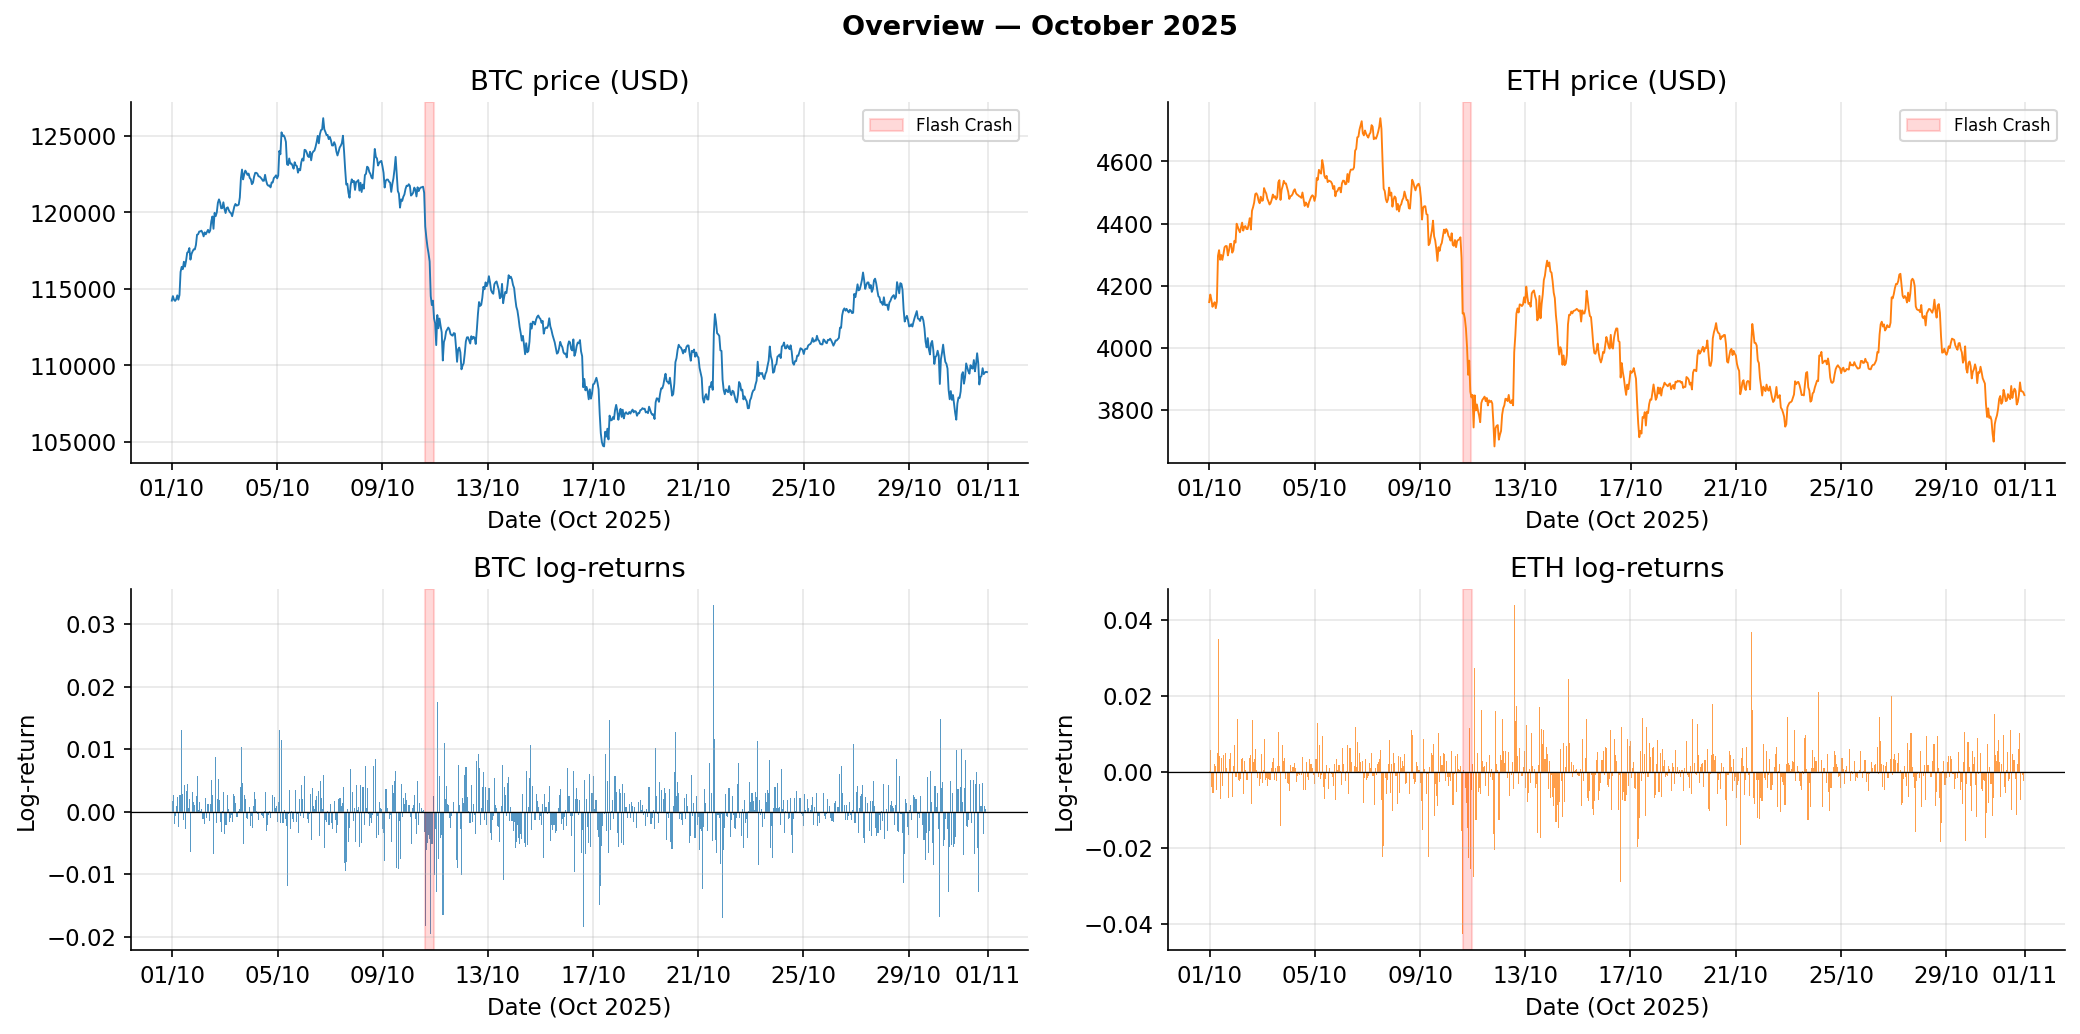


TABLE 1 — Descriptive statistics of log-returns
           n  Mean (×1e-4)  Std dev (%)  Skewness  Excess kurtosis  Min (%)  Max (%)
Series                                                                              
BTC     8603       -0.0864       0.4959   -2.8477          84.1581 -14.0029   4.9592
ETH     8603       -0.1440       0.7946   -1.6078          40.8483 -16.8052   9.6508

TABLE 2 — Stationarity tests (ADF and KPSS)
             Statistic  p-value  Lags   CV 1%   CV 5%       Decision
Series Test                                                         
BTC    ADF    -22.2844      0.0    21 -3.4311 -2.8619  Stationary***
       KPSS     0.1376      0.1    13  0.7390  0.4630     Stationary
ETH    ADF    -18.9704      0.0    25 -3.4311 -2.8619  Stationary***
       KPSS     0.1878      0.1     6  0.7390  0.4630     Stationary
[FIGURE] figures/fig_acf_pacf_btc.pdf saved


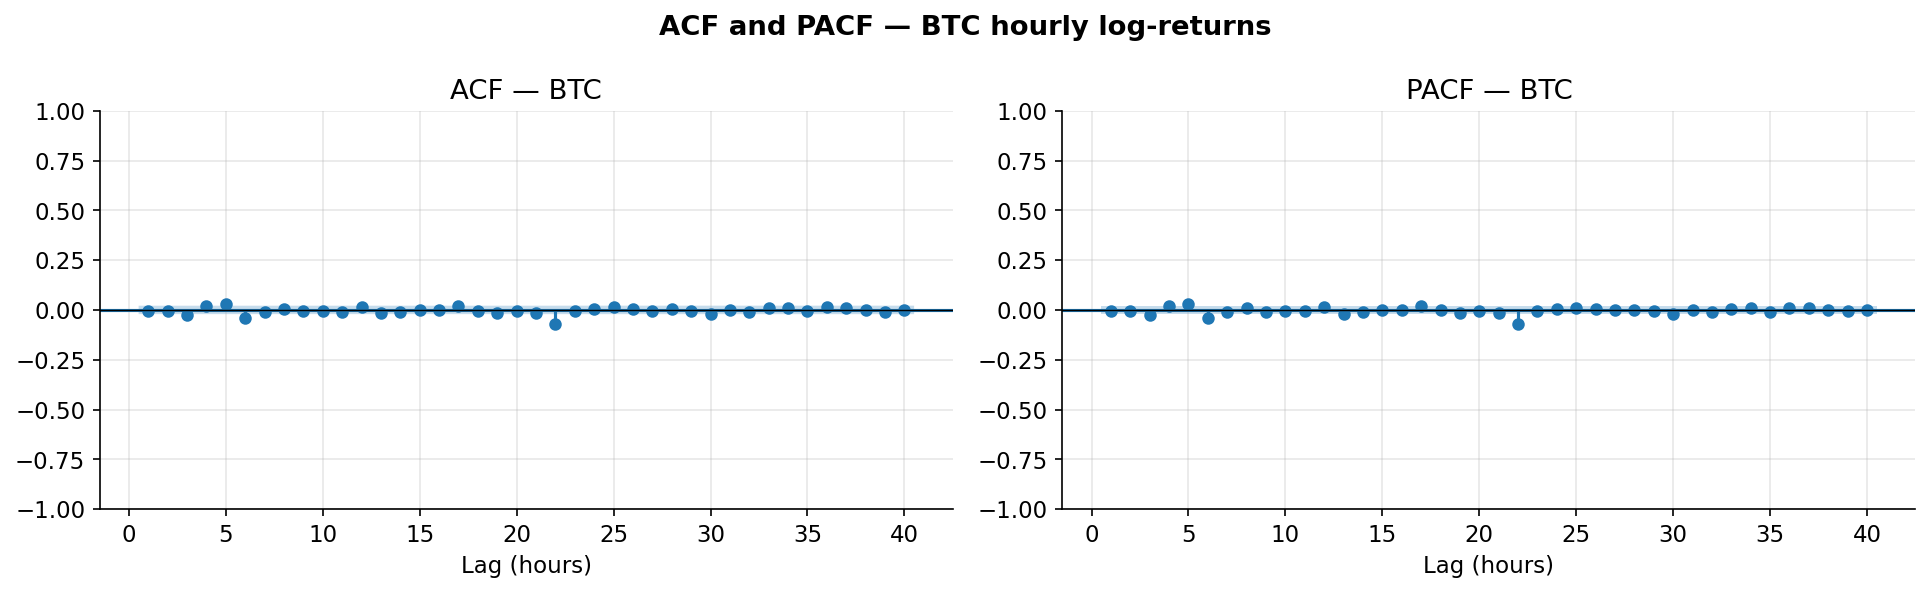

[FIGURE] figures/fig_acf_pacf_eth.pdf saved


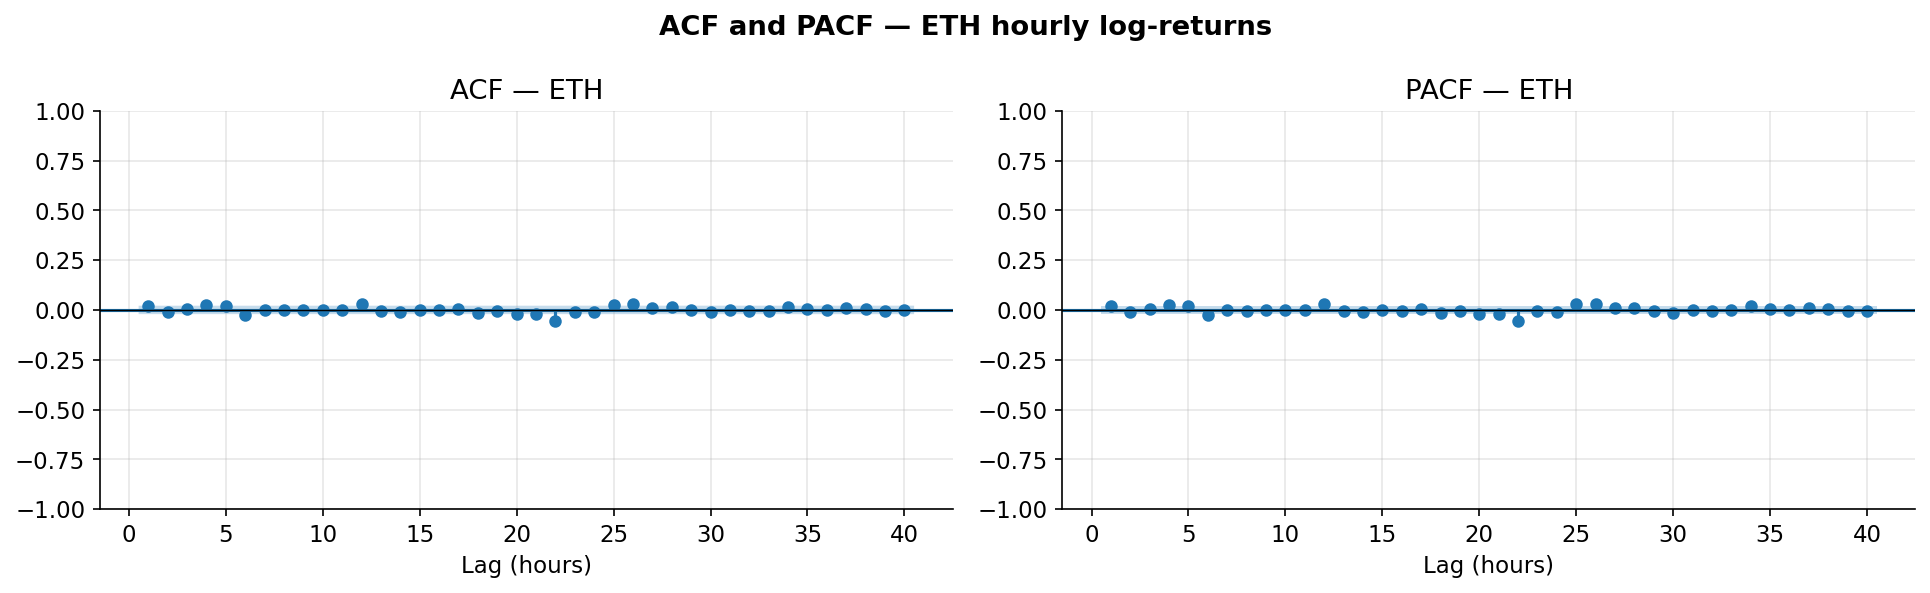


[ARMA grid] BTC — fitting 24 models...

Top 5 specifications by BIC — BTC:
 p  q       AIC       BIC      HQIC
 0  1 -66885.71 -66864.53 -66878.49
 1  0 -66885.71 -66864.53 -66878.48
 0  2 -66883.93 -66855.69 -66874.30
 2  0 -66883.92 -66855.68 -66874.29
 1  1 -66883.21 -66854.97 -66873.57

[ARMA grid] ETH — fitting 24 models...

Top 5 specifications by BIC — ETH:
 p  q       AIC       BIC      HQIC
 0  1 -58775.80 -58754.62 -58768.58
 1  0 -58775.72 -58754.54 -58768.50
 1  1 -58775.09 -58746.85 -58765.46
 0  2 -58774.95 -58746.71 -58765.31
 2  0 -58774.95 -58746.71 -58765.32

[SELECT] BTC -> ARMA(0,1)
[SELECT] ETH -> ARMA(0,1)

ARMA(0,1) — BTC
                               SARIMAX Results                                
Dep. Variable:                BTC-USD   No. Observations:                 8603
Model:                 ARIMA(0, 0, 1)   Log Likelihood               33445.857
Date:                Sun, 29 Mar 2026   AIC                         -66885.713
Time:                        1

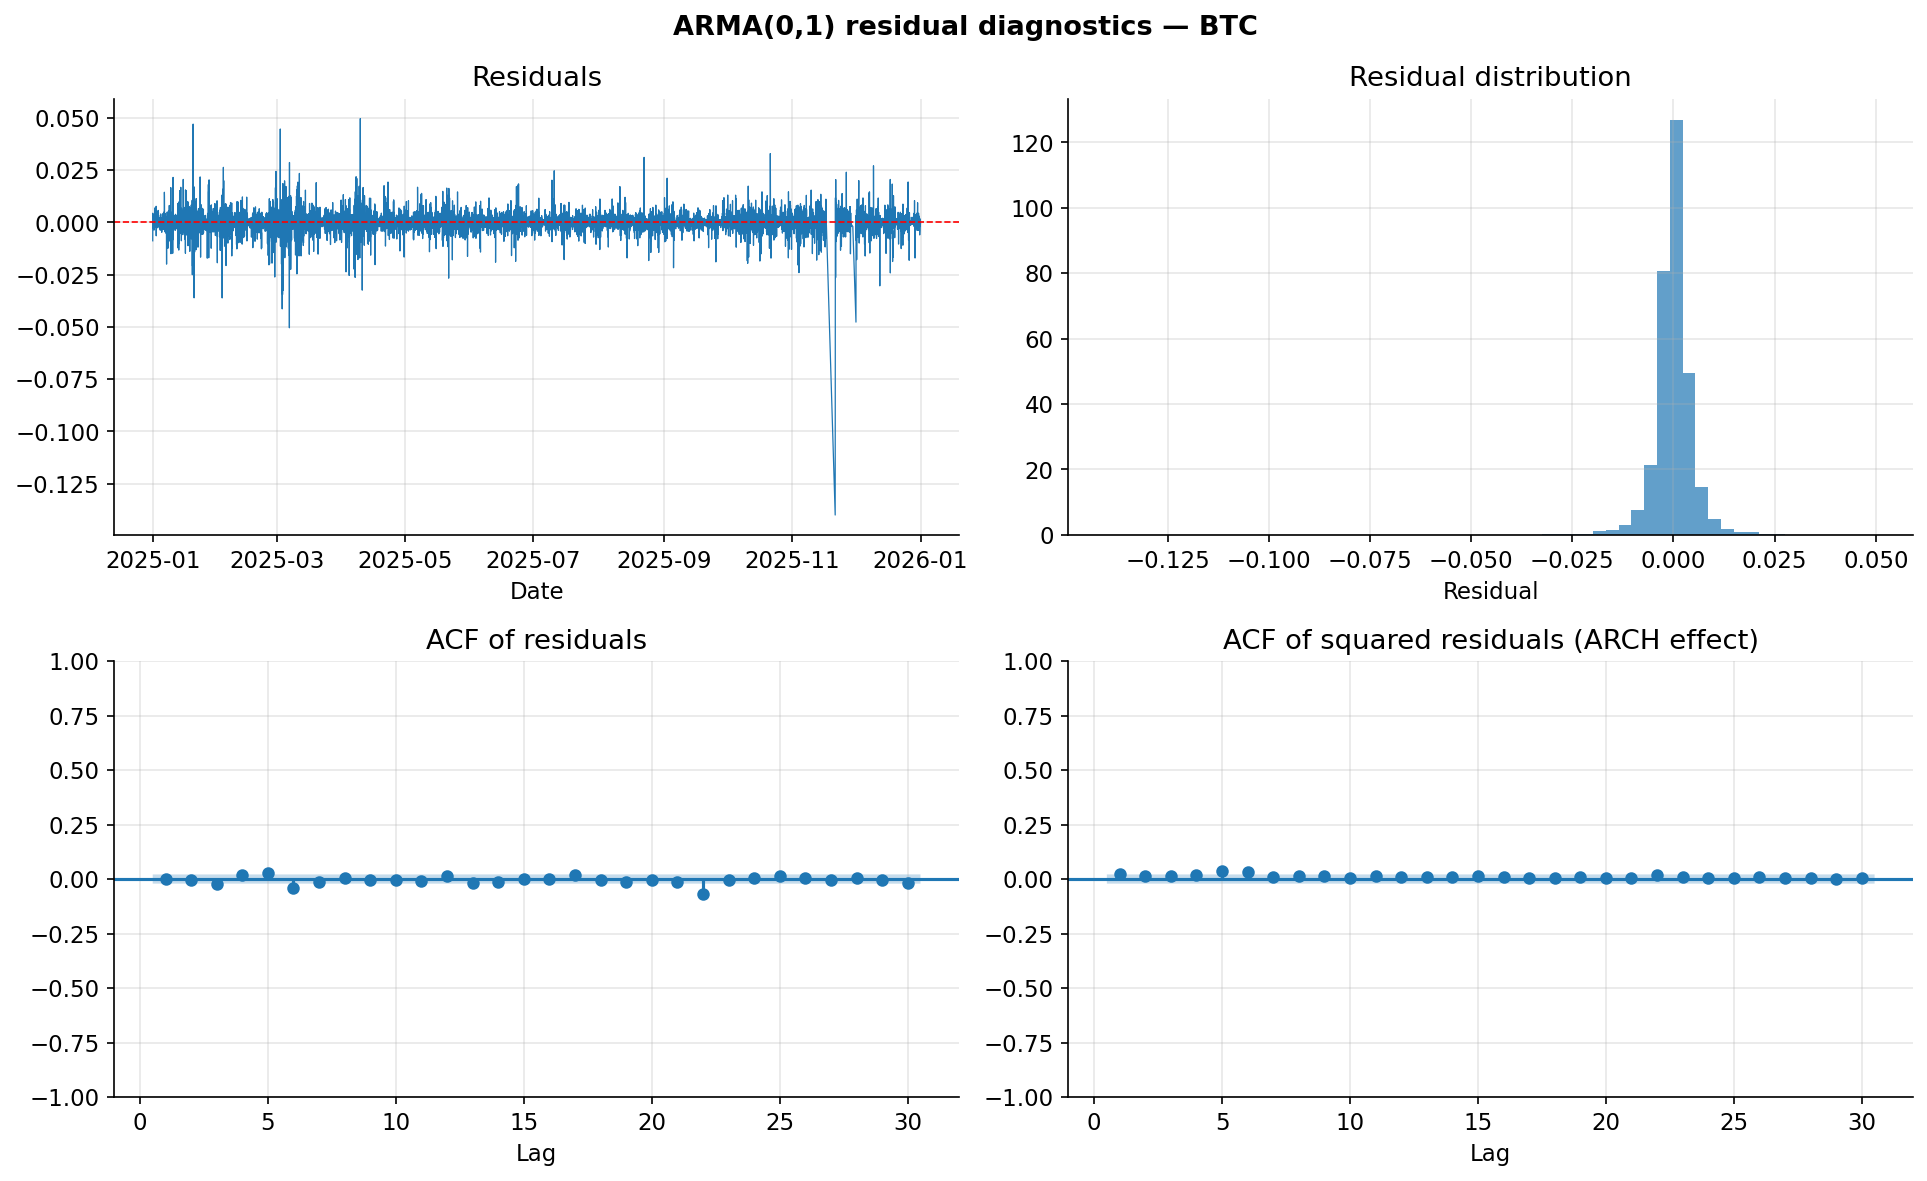


ARMA(0,1) — ETH
                               SARIMAX Results                                
Dep. Variable:                ETH-USD   No. Observations:                 8603
Model:                 ARIMA(0, 0, 1)   Log Likelihood               29390.901
Date:                Sun, 29 Mar 2026   AIC                         -58775.803
Time:                        15:49:36   BIC                         -58754.623
Sample:                             0   HQIC                        -58768.579
                               - 8603                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const      -1.493e-05   9.02e-05     -0.166      0.868      -0.000       0.000
ma.L1          0.0202      0.008      2.540      0.011       0.005       0.036
sigma2      6.311e-05   2.19e-07   

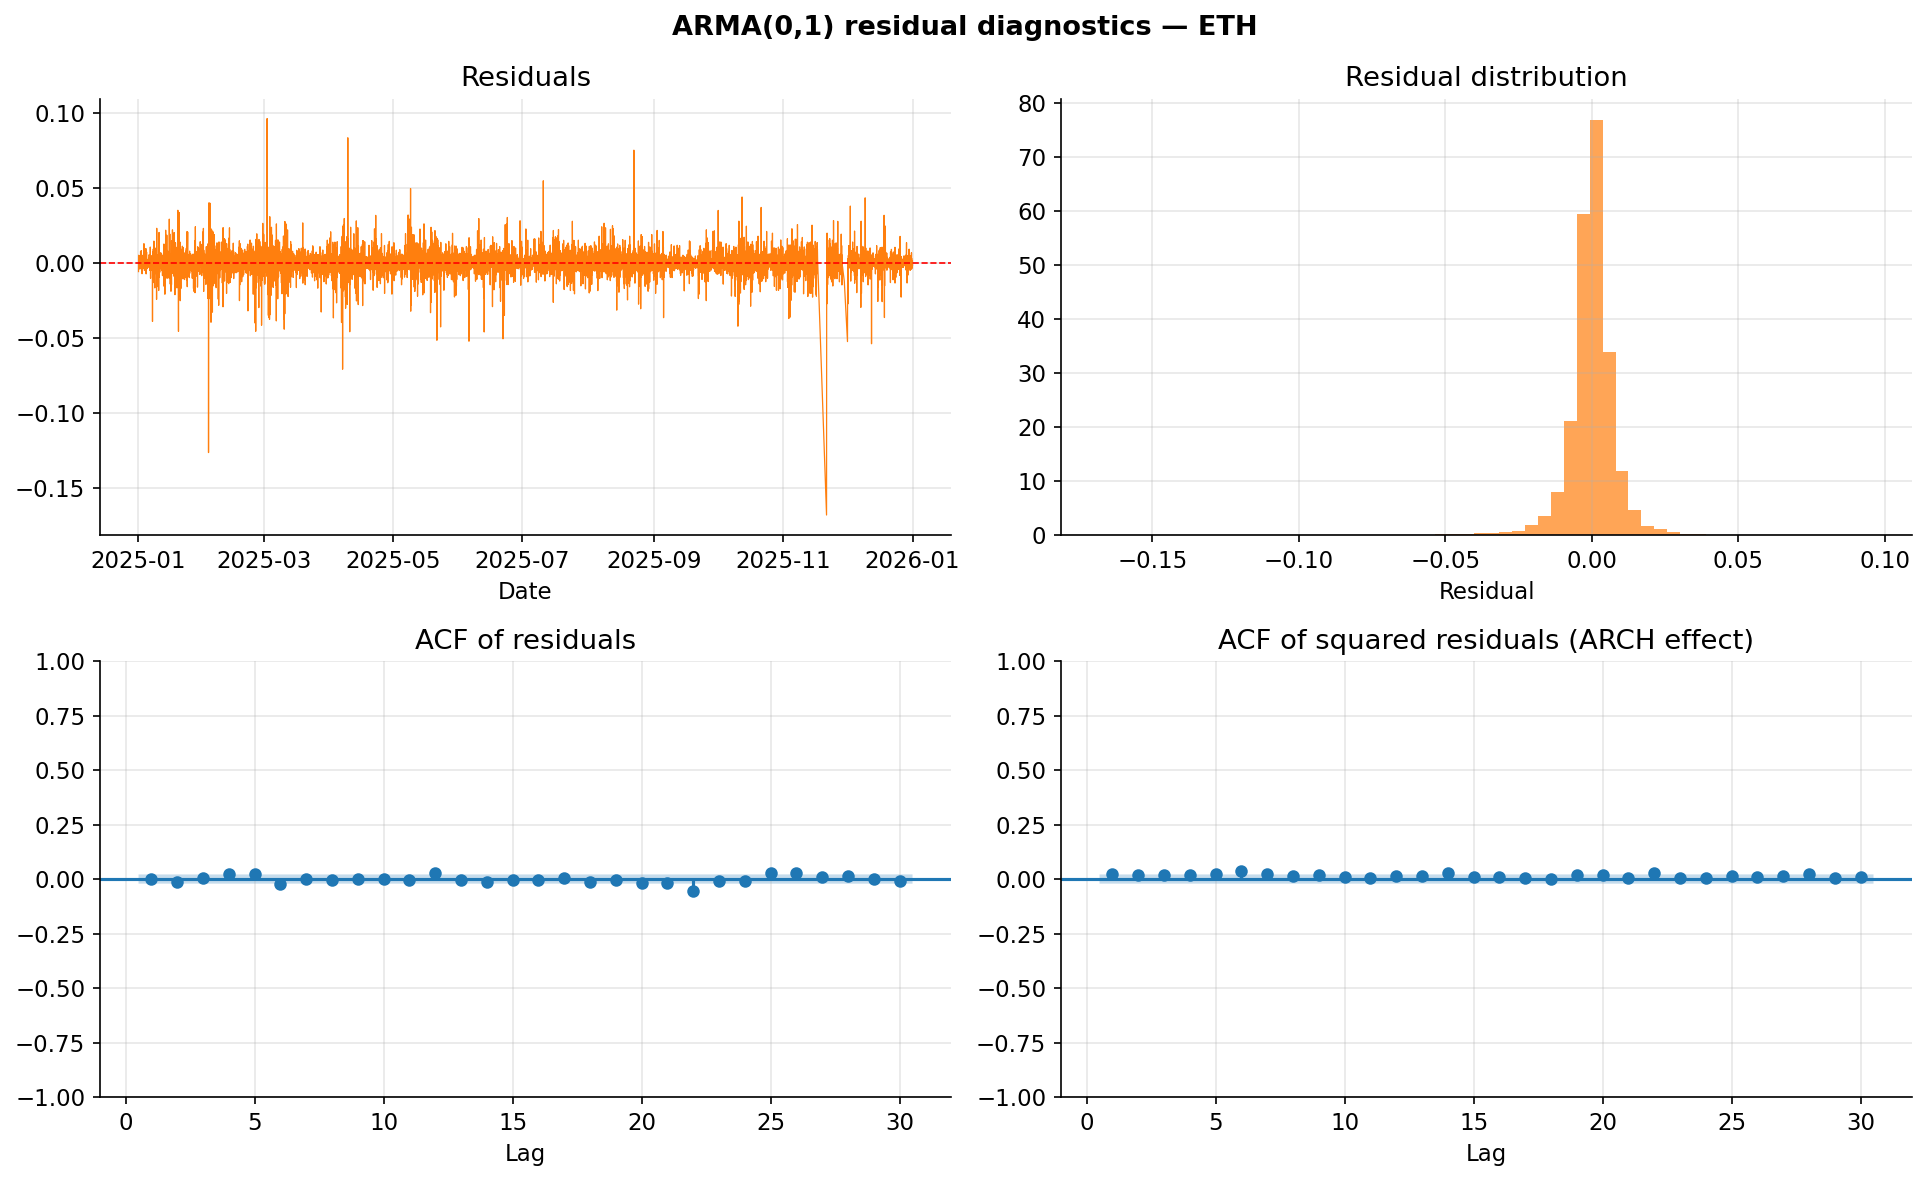

[FIGURE] figures/fig_spectral_btc.pdf saved


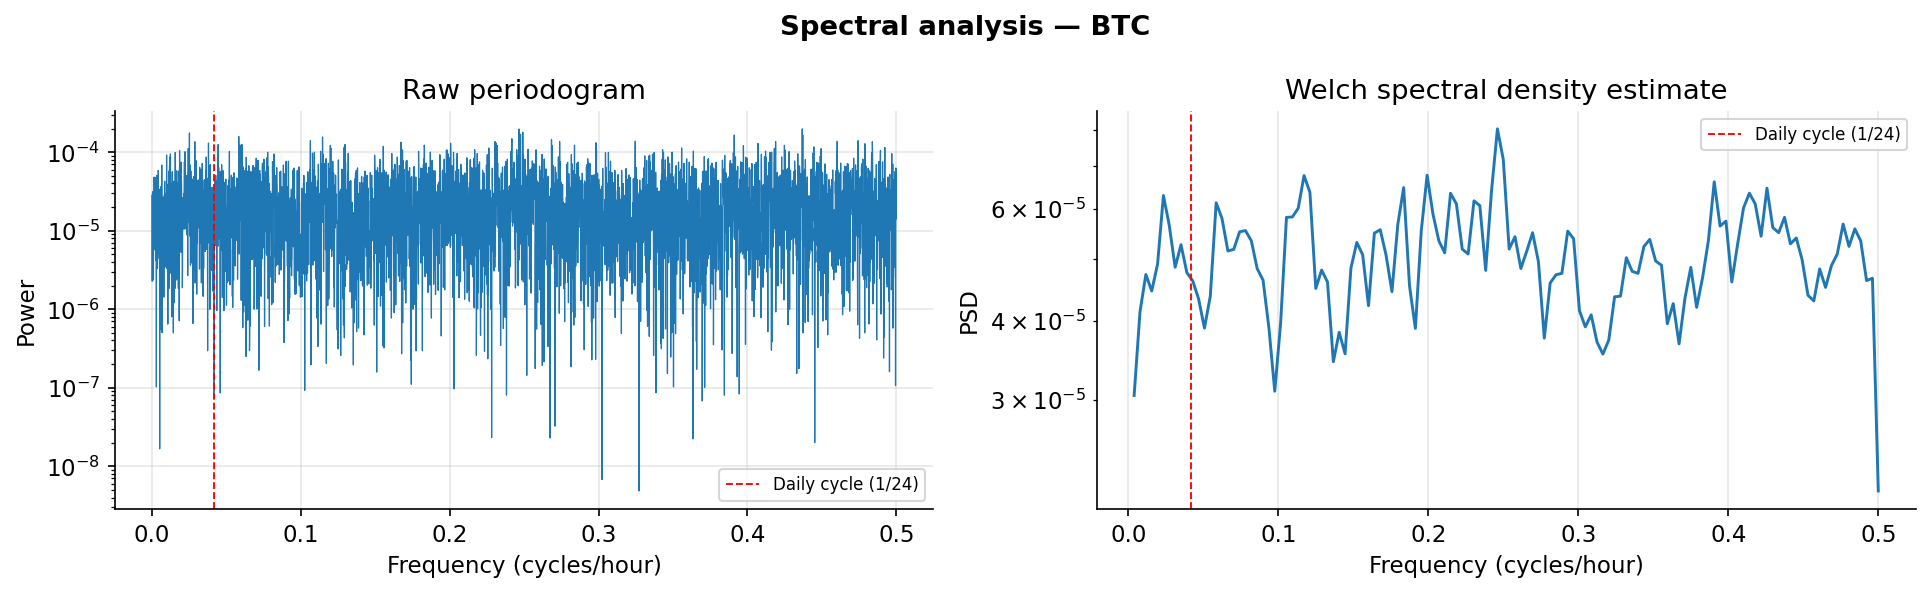

[FIGURE] figures/fig_spectral_eth.pdf saved


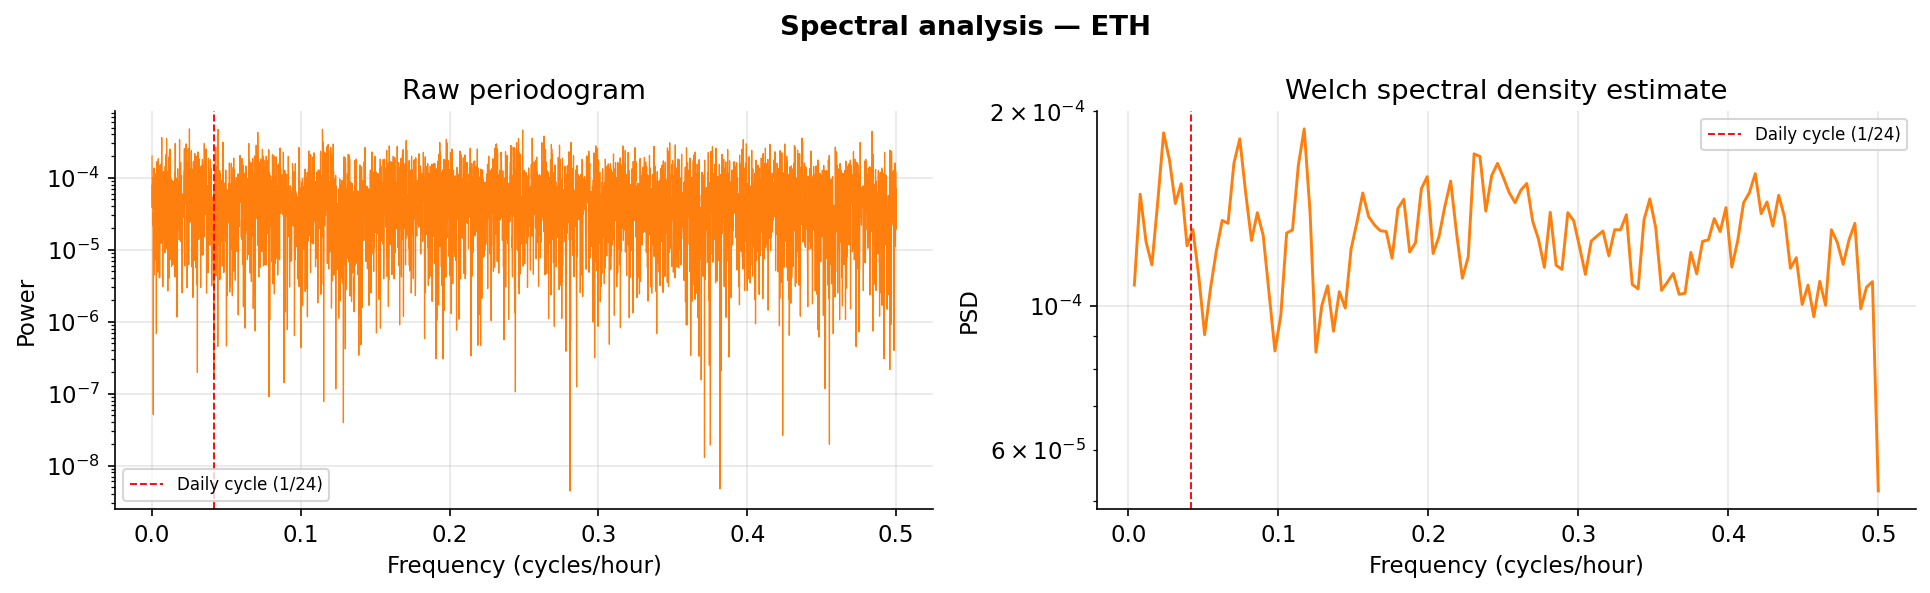


TABLE 3 — Hurst exponent (R/S analysis)
  BTC : H = 0.5395  (random walk)
  ETH : H = 0.5526  (long memory)
[FIGURE] figures/fig_hurst_rs.pdf saved


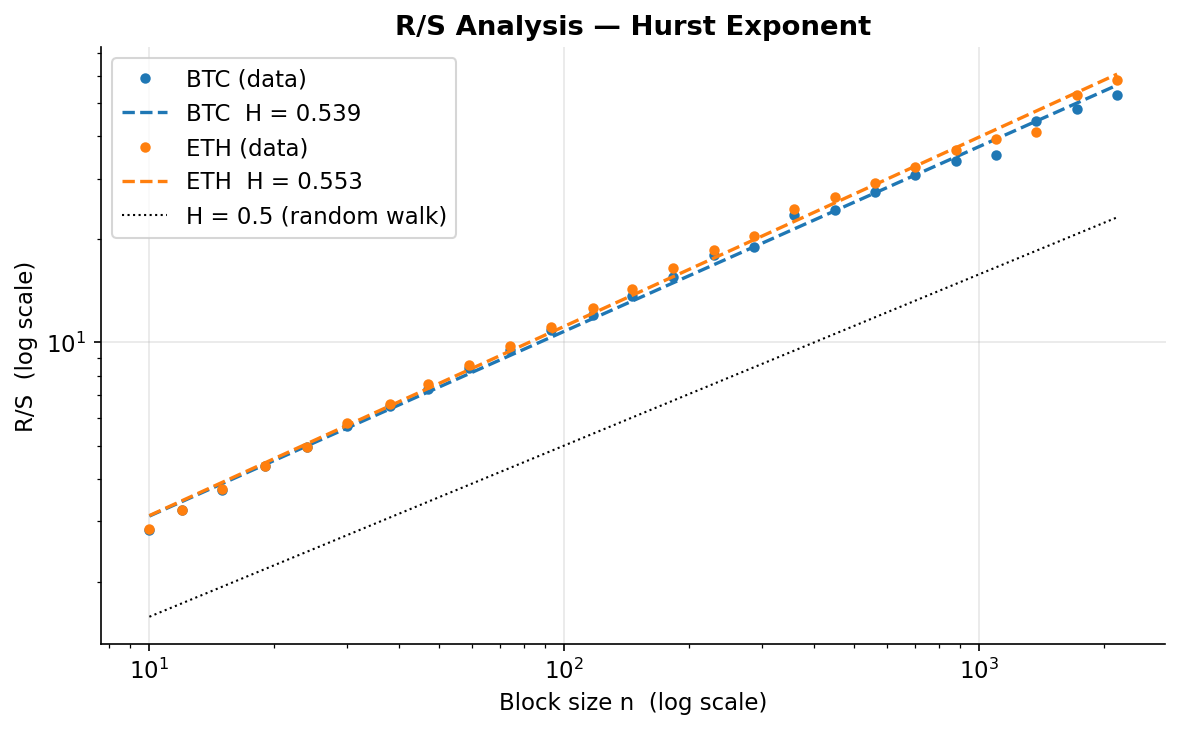


TABLE 4 — GPH fractional differencing parameter d

[GPH — BTC]
  d_hat = 0.0227   SE = 0.0794   t = 0.2855
  95% CI : [-0.1329, 0.1782]
  Interpretation: short memory / ARMA sufficient
[FIGURE] figures/fig_gph_btc.pdf saved


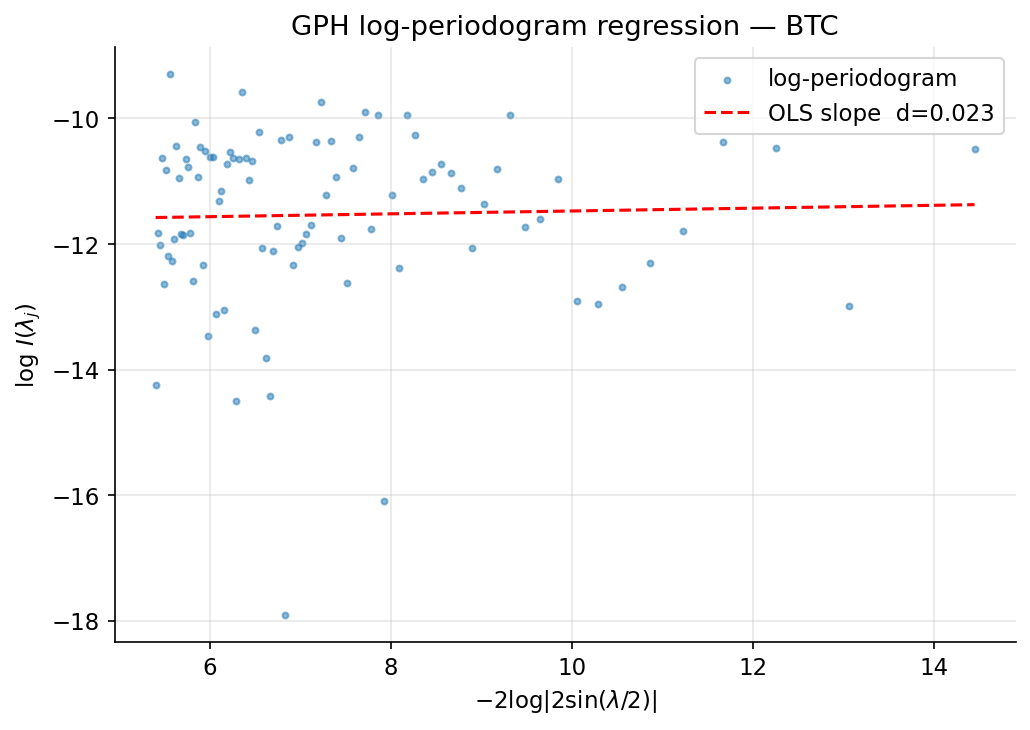


[GPH — ETH]
  d_hat = 0.0076   SE = 0.0763   t = 0.0995
  95% CI : [-0.1420, 0.1572]
  Interpretation: short memory / ARMA sufficient
[FIGURE] figures/fig_gph_eth.pdf saved


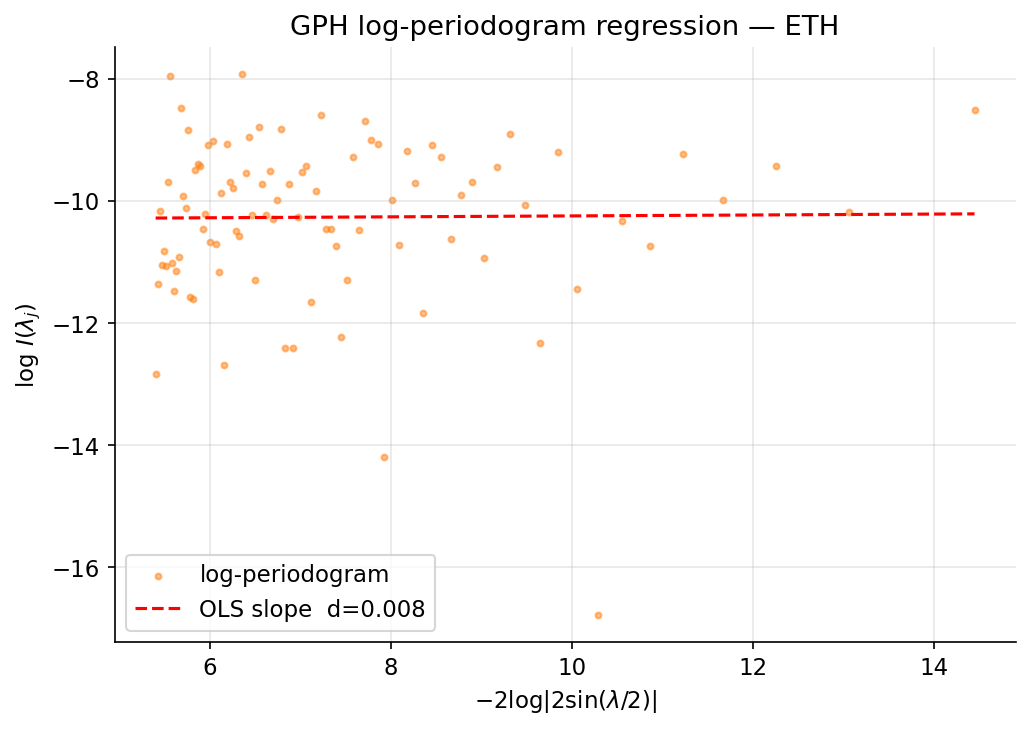


TABLE 5 — Minimum d for stationarity (log-price series)

BTC  (minimum d = 0.25):
   d  ADF stat  p-value
0.00   -1.4811   0.5428
0.05   -1.2683   0.6435
0.10   -1.4465   0.5598
0.15   -1.8905   0.3366
0.20   -2.4154   0.1374
0.25   -2.9879   0.0360
0.30   -4.3128   0.0004
0.35   -4.8241   0.0000
0.40   -5.8826   0.0000
0.45   -7.1168   0.0000
0.50   -8.3975   0.0000
0.55   -9.7618   0.0000
0.60  -11.1596   0.0000
0.65  -12.5465   0.0000
0.70  -13.7823   0.0000
0.75  -14.9568   0.0000
0.80  -16.1718   0.0000
0.85  -17.3343   0.0000
0.90  -20.4701   0.0000
0.95  -21.4147   0.0000
1.00  -22.2844   0.0000

ETH  (minimum d = 0.25):
   d  ADF stat  p-value
0.00   -1.2328   0.6593
0.05   -1.6697   0.4468
0.10   -1.8691   0.3468
0.15   -2.1352   0.2306
0.20   -2.6237   0.0882
0.25   -3.7408   0.0036
0.30   -3.8116   0.0028
0.35   -3.4665   0.0089
0.40   -4.2863   0.0005
0.45   -4.9008   0.0000
0.50   -5.8347   0.0000
0.55   -6.9347   0.0000
0.60   -7.9801   0.0000
0.65  -10.4345   0.0000
0.7

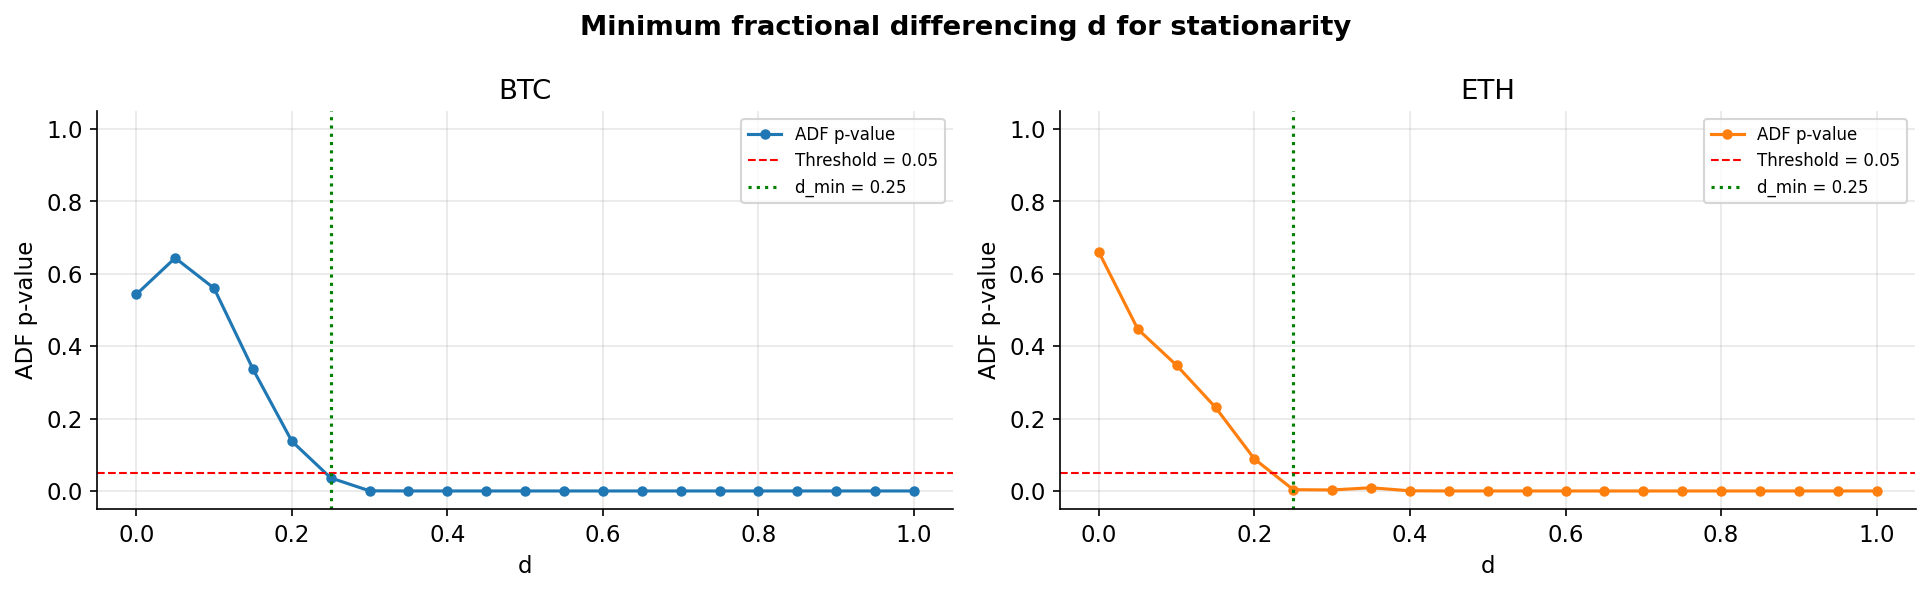

In [15]:
# ============================================================
# MAIN — Run all analyses in order
# ============================================================
if __name__ == "__main__":
 
    # ── 1. Load data ──────────────────────────────────────────
    btc_price, eth_price = load_data()
    btc_ret = log_returns(btc_price)
    eth_ret = log_returns(eth_price)
    returns = {"BTC": btc_ret, "ETH": eth_ret}
 
    # ── 2. Overview figure ───────────────────────────────────
    plot_overview(btc_price, eth_price, btc_ret, eth_ret)
 
    # ── 3. Table 1 — Descriptive statistics ─────────────────
    print("\n" + "="*60)
    print("TABLE 1 — Descriptive statistics of log-returns")
    print("="*60)
    desc = descriptive_stats(returns)
    print(desc.to_string())
 
    # ── 4. Table 2 — Stationarity tests ─────────────────────
    print("\n" + "="*60)
    print("TABLE 2 — Stationarity tests (ADF and KPSS)")
    print("="*60)
    stat_df = run_stationarity_tests(returns)
    print(stat_df.to_string())
 
    # ── 5. ACF / PACF figures ────────────────────────────────
    for name, s in returns.items():
        plot_acf_pacf(s, name, lags=40)
 
    # ── 6. ARMA order selection ──────────────────────────────
    grid_btc = select_arma_order(btc_ret, "BTC", p_max=4, q_max=4)
    grid_eth = select_arma_order(eth_ret, "ETH", p_max=4, q_max=4)
 
    best_btc = grid_btc.iloc[0]
    best_eth = grid_eth.iloc[0]
    p_btc, q_btc = int(best_btc.p), int(best_btc.q)
    p_eth, q_eth = int(best_eth.p), int(best_eth.q)
    print(f"\n[SELECT] BTC -> ARMA({p_btc},{q_btc})")
    print(f"[SELECT] ETH -> ARMA({p_eth},{q_eth})")
 
    # ── 7. Estimation + diagnostics ──────────────────────────
    mod_btc = fit_best_arma(btc_ret, p_btc, q_btc, "BTC")
    mod_eth = fit_best_arma(eth_ret, p_eth, q_eth, "ETH")
 
    # ── 8. Spectral analysis ─────────────────────────────────
    plot_periodogram(btc_ret, "BTC")
    plot_periodogram(eth_ret, "ETH")
 
    # ── 9. Hurst exponent ────────────────────────────────────
    print("\n" + "="*60)
    print("TABLE 3 — Hurst exponent (R/S analysis)")
    print("="*60)
    for name, s in returns.items():
        H = hurst_rs(s)
        label = ("long memory"   if H > 0.55 else
                 "random walk"   if H > 0.45 else
                 "anti-persistent")
        print(f"  {name} : H = {H:.4f}  ({label})")
    plot_hurst(returns)
 
    # ── 10. GPH estimator (fractional d) ─────────────────────
    print("\n" + "="*60)
    print("TABLE 4 — GPH fractional differencing parameter d")
    print("="*60)
    d_btc, se_btc = gph_estimator(btc_ret, "BTC")
    d_eth, se_eth = gph_estimator(eth_ret, "ETH")
 
    # ── 11. Fractional differencing — minimum d ───────────────
    print("\n" + "="*60)
    print("TABLE 5 — Minimum d for stationarity (log-price series)")
    print("="*60)
    prices = {"BTC": btc_price, "ETH": eth_price}
    d_min_results = {}
    for name, price in prices.items():
        d_min, d_table = find_min_d(price)
        d_min_results[name] = d_min
        print(f"\n{name}  (minimum d = {d_min}):")
        print(d_table.to_string(index=False))
 
    plot_min_d(prices)
 


In [16]:
    # ── Final summary ─────────────────────────────────────────
    H_btc = hurst_rs(btc_ret)
    H_eth = hurst_rs(eth_ret)
    print("\n" + "="*60)
    print("SECTION 3 — Summary of key results")
    print("="*60)
    print(f"  Stationarity  : see Table 2")
    print(f"  Best ARMA     : BTC -> ARMA({p_btc},{q_btc})  |  ETH -> ARMA({p_eth},{q_eth})")
    print(f"  Hurst H       : BTC = {H_btc:.3f}  |  ETH = {H_eth:.3f}")
    print(f"  GPH d         : BTC = {d_btc:.3f} (SE={se_btc:.3f})  "
          f"|  ETH = {d_eth:.3f} (SE={se_eth:.3f})")
    print(f"  Min d (price) : BTC = {d_min_results['BTC']}  "
          f"|  ETH = {d_min_results['ETH']}")
    print("\n[DONE] All figures saved in ./figures/")



SECTION 3 — Summary of key results
  Stationarity  : see Table 2
  Best ARMA     : BTC -> ARMA(0,1)  |  ETH -> ARMA(0,1)
  Hurst H       : BTC = 0.539  |  ETH = 0.553
  GPH d         : BTC = 0.023 (SE=0.079)  |  ETH = 0.008 (SE=0.076)
  Min d (price) : BTC = 0.25  |  ETH = 0.25

[DONE] All figures saved in ./figures/
